In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
import torch
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../")
import InfoGlobe
from InfoGlobe.metrics import fisher_rao_dis_matrix
from InfoGlobe.utils import get_knn
from InfoGlobe.filter import global_variance_vary, greedy_var

/home/wangcheng/anaconda3/envs/MarkovMF/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [ ]:
adata = sc.read_h5ad("raw_data.h5ad")
adata = adata[:, adata.var['highly_variable_genes']==True].copy()

In [36]:
P = adata.X.toarray().copy()
P = P / P.sum(axis=1, keepdims=True)
P_gd = P.T

In [ ]:
n, m = P_gd.shape
k = 50

model = InfoGlobe.infoglobe.GlobeEmbedding(A = [n,k], Q = [k,m], c=1)
model.fit(torch.Tensor(P_gd), max_iter=30000)

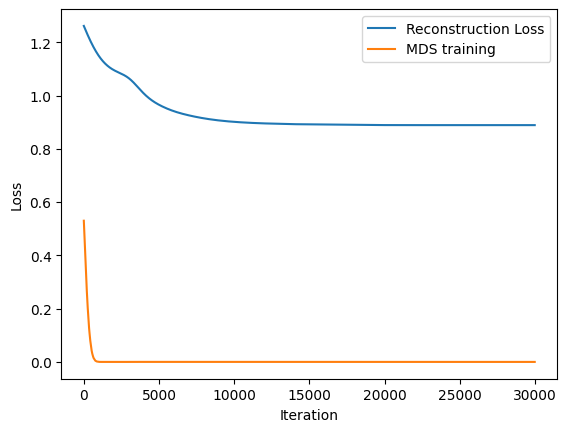

In [ ]:
x = x = [i*10 for i in range(len(MMF.loss1))] 

plt.plot(x, model.loss1, label='Reconstruction Loss')
plt.plot(x, model.loss2, label='MDS training')
# plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
adata.obsm['infoglobe_embedding'] = model.Q.detach().cpu().numpy().T
adata.varm['infoglobe_kernel'] = model.A.detach().cpu().numpy()

In [17]:
fisher_dis_mat = fisher_rao_dis_matrix(torch.tensor(adata.obsm['infoglobe_embedding'].T))
dis_mat, knn_mat = get_knn(fisher_dis_mat, k=50)

adata.obsp['connectivities'] = knn_mat
adata.obsp['distances'] = dis_mat

In [20]:
adata.uns['neighbors'] = {
    'params': {
        'n_neighbors': 50,
        'method': 'umap',
        'metric': 'fisher_rao',
        # 可以添加其他 Scanpy 期望的参数，如：
        'use_rep': 'infoglobe_embedding', # 告诉 UMAP/Leiden 使用哪个数据表示来计算邻居 (即使您是预计算的)
    },
    
    # 保持不变：指向 obsp 中的矩阵
    'connectivities_key': 'connectivities',
    'distances_key': 'distances',
}
sc.tl.umap(adata, init_pos='random', min_dist=1.2)

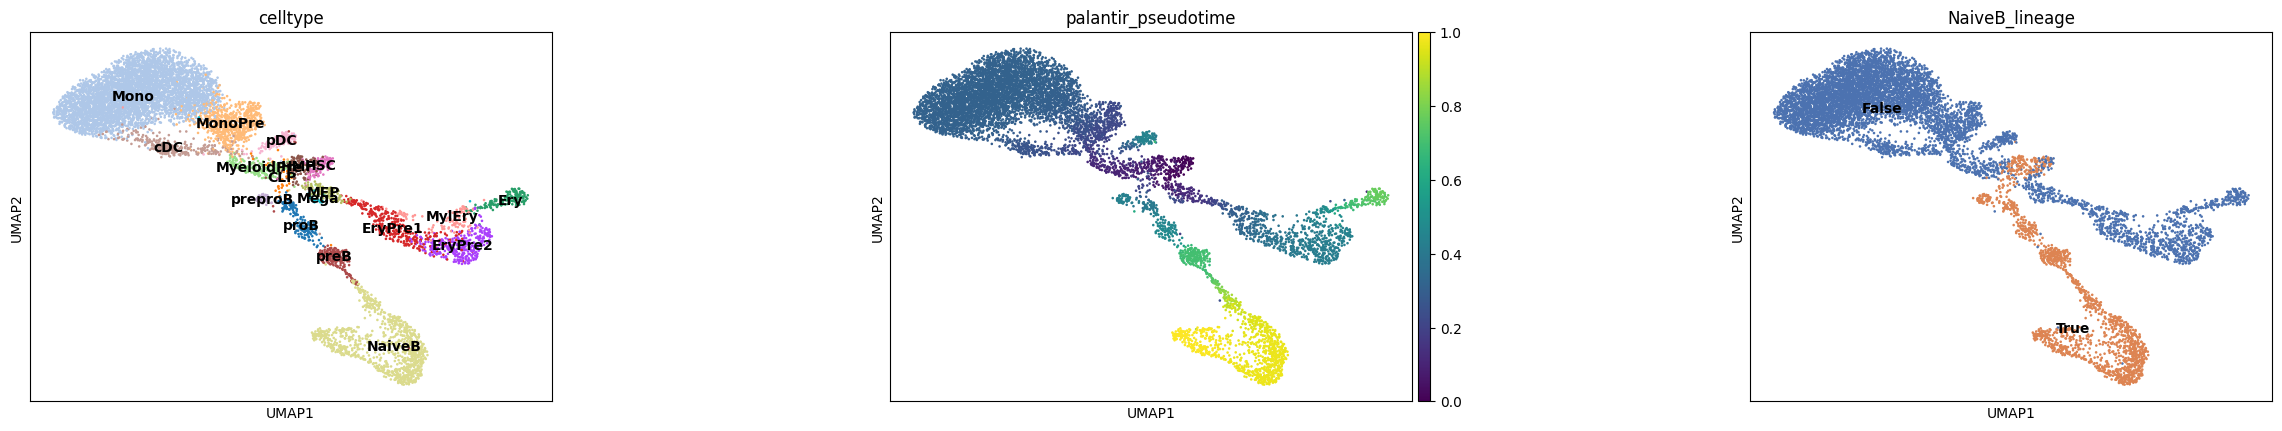

In [21]:
sc.pl.umap(adata, color=['celltype', 'palantir_pseudotime', 'NaiveB_lineage'], wspace=0.5, legend_loc='on data')